### Loading

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df= pd.read_csv("../data/processed/upl_goals_2019_2025_cleaned.csv")

In [49]:
# df.head()
# df.shape
# df.info()
# df.describe()
# df.isna().sum()

### Preprocessing

In [50]:
# normalize column names: strip whitespace, lowercase, replace spaces (and other whitespace) with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)

In [51]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='coerce') # parse ISO-format dates (YYYY-MM-DD); coerce invalid formats to NaT
df['goal_minute_num'] = pd.to_numeric(df['goal_minute_num'], errors='coerce') 

In [52]:
# strip leading/trailing whitespace for all object dtype columns in-place
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].apply(lambda v: v.strip() if isinstance(v, str) else v)

In [53]:
df.replace("", np.nan, inplace=True)

In [54]:
df = df[df['season'] != '2025/26'] # exclude 2025/26 season which is ongoing and has incomplete data

In [55]:
df = df[df['in_added_time']== 0] #excluse goals which were scored in added/extra time

### Sanity Checks

In [56]:
len(df['match_day'].unique().tolist()) # 30 match days per season for UPL, as expected

30

In [57]:
(len(df['home_team'].unique().tolist())) == (len(df['away_team'].unique().tolist())) # 16 unique home teams and 16 unique away teams, as expected for a 16-team league with no team name inconsistencies between home/away columns

True

In [58]:
16*15*2 # 16 teams, each playing 15 opponents twice (home and away) = 480 total matches in the dataset for each season; with 6 seasons (2019/20 through 2024/25) in the dataset, we would expect 480*6 = 2880 total matches

480

In [59]:
float(round((1-(df.groupby('season')['match_id'].nunique().sum() / ((240*5)+210))) *100,3)) # calculate percentage of matches with missing goal data across all seasons; 240 matches per season for 5 full seasons (2019/20 through 2024/25) plus 210 matches for the incomplete 2022/23 season, for a total of 1410 expected matches in the dataset; compare to actual unique match_id count to determine percentage of matches with missing goal data

8.652

In [60]:
df.groupby('season')[['home_team','away_team']].nunique() # should be 16 for home and 15 for away,except in 2022/23 which had 15 after promoted Kyetume FC failed to receive a license in time for the fixture list to be released

,home_team,away_team
season,,
2019/20,16,16
2020/21,16,16
2021/22,16,16
2022/23,15,15
2023/24,16,16
2024/25,16,16


## Timing Patterns

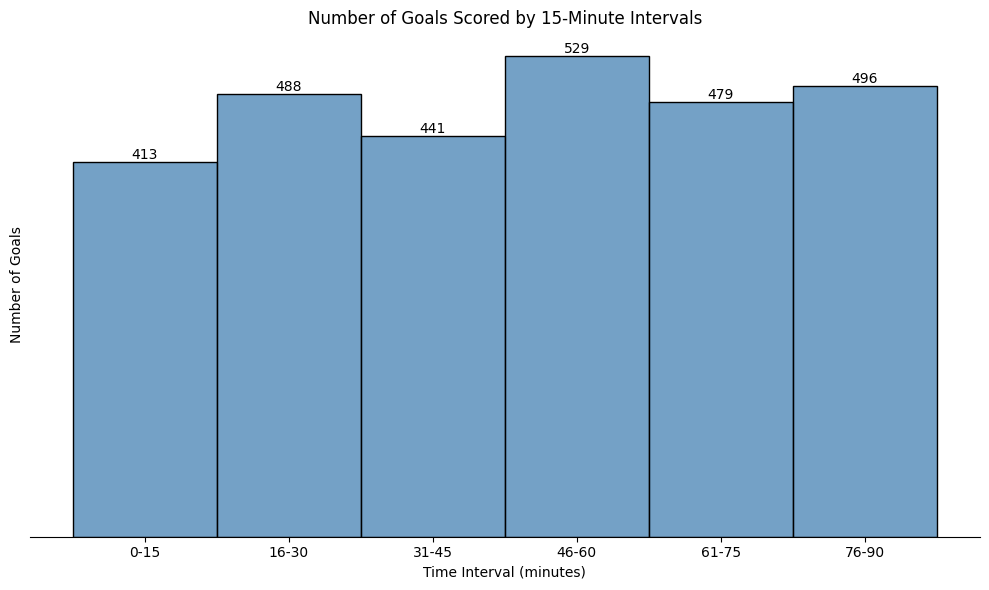

In [67]:
# Create bins for 15-minute intervals
bins = [0, 15, 30, 45, 60, 75, 90]
labels = ['0-15', '16-30', '31-45', '46-60', '61-75', '76-90']

# Bin the goal_minute_num into 15-minute intervals
df['15_goal_interval'] = pd.cut(df['goal_minute_num'], bins=bins, labels=labels, right=False)

# Create histogram using seaborn
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df, x='15_goal_interval', discrete=True, kde=False, color='steelblue')

# Get the bar patches
patches = [patch for patch in ax.patches]

# Add total count on top of each bar
for patch in patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove yticks and labels
ax.set_yticks([])

plt.title('Number of Goals Scored by 15-Minute Intervals')
plt.xlabel('Time Interval (minutes)')
plt.ylabel('Number of Goals')
plt.tight_layout()
plt.show()

In [68]:
# Group by 'goal_interval' and count the number of goals
goal_counts = df.groupby('15_goal_interval',observed=True).size().reset_index(name='goal_count')
goal_counts

,15_goal_interval,goal_count
0,0-15,413
1,16-30,488
2,31-45,441
3,46-60,529
4,61-75,479
5,76-90,496


Most goals are scored in the 46-60 interval

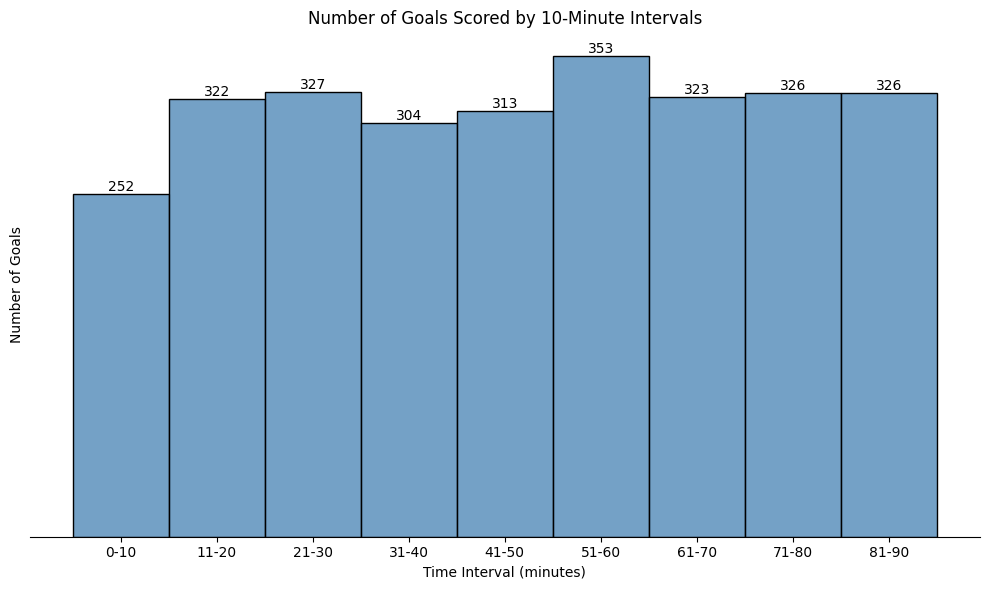

In [69]:
# Create bins for 10-minute intervals
bins = [0,10,20, 30, 40, 50, 60, 70,80, 90]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90']

# Bin the goal_minute_num into 10-minute intervals
df['10_minute_interval'] = pd.cut(df['goal_minute_num'], bins=bins, labels=labels, right=False)

# Create histogram using seaborn
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df, x='10_minute_interval', discrete=True, kde=False, color='steelblue')

# Get the bar patches
patches = [patch for patch in ax.patches]

# Add total count on top of each bar
for patch in patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove yticks and labels
ax.set_yticks([])

plt.title('Number of Goals Scored by 10-Minute Intervals')
plt.xlabel('Time Interval (minutes)')
plt.ylabel('Number of Goals')
plt.tight_layout()
plt.show()

In [70]:
# Group by 'goal_interval' and count the number of goals
goal_counts10 = df.groupby('10_minute_interval',observed=True).size().reset_index(name='goal_count')
goal_counts10

,10_minute_interval,goal_count
0,0-10,252
1,11-20,322
2,21-30,327
3,31-40,304
4,41-50,313
5,51-60,353
6,61-70,323
7,71-80,326
8,81-90,326


Most goals are scored in the 51-60 interval

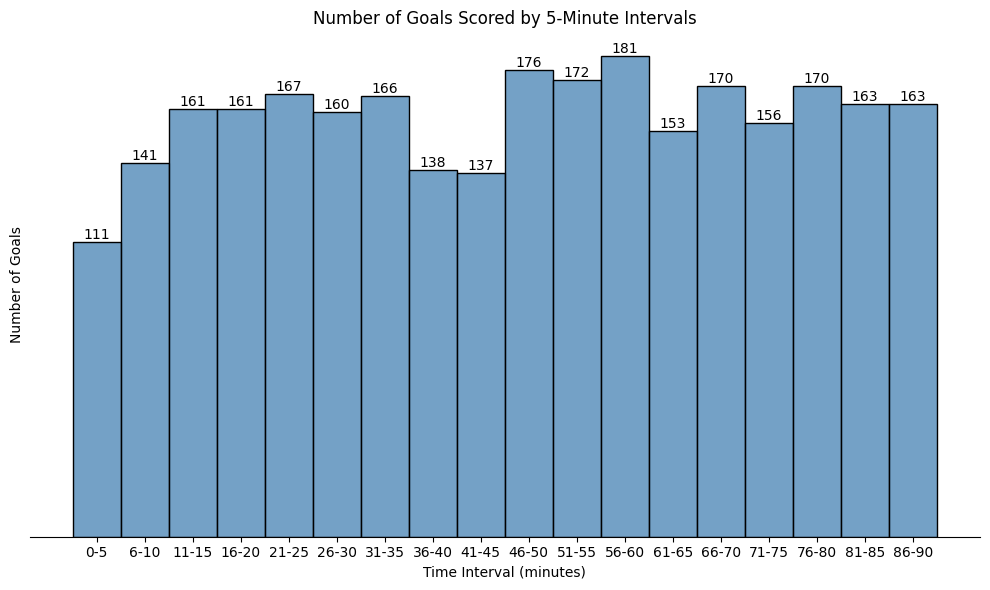

In [71]:
# Create bins for 5-minute intervals
bins = [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90] 
labels = ['0-5','6-10','11-15','16-20','21-25','26-30','31-35','36-40','41-45','46-50','51-55','56-60','61-65','66-70','71-75','76-80','81-85','86-90']
# Bin the goal_minute_num into 5-minute intervals
df['5_minute_interval'] = pd.cut(df['goal_minute_num'], bins=bins, labels=labels, right=False)

# Create histogram using seaborn
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df, x='5_minute_interval', discrete=True, kde=False, color='steelblue')

# Get the bar patches
patches = [patch for patch in ax.patches]

# Add total count on top of each bar
for patch in patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove yticks and labels
ax.set_yticks([])

plt.title('Number of Goals Scored by 5-Minute Intervals')
plt.xlabel('Time Interval (minutes)')
plt.ylabel('Number of Goals')
plt.tight_layout()
plt.show()


In [74]:
# Group by 'goal_interval' and count the number of goals
goal_counts5 = df.groupby('5_minute_interval',observed=True).size().reset_index(name='goal_count')
goal_counts5

,5_minute_interval,goal_count
0,0-5,111
1,6-10,141
2,11-15,161
3,16-20,161
4,21-25,167
5,26-30,160
6,31-35,166
7,36-40,138
8,41-45,137
9,46-50,176


Most goals are in the 56-60th minute

In [ ]:
# Get unique seasons
seasons = df['season'].unique()
num_seasons = len(seasons)

# Create a figure with subplots (side by side)
fig, axes = plt.subplots(1, num_seasons, figsize=(4*num_seasons, 5), sharey=True)

# If only one season, axes is not an array
if num_seasons == 1:
    axes = [axes]

for idx, season in enumerate(sorted(seasons)):
    season_data = df[df['season'] == season]
    
    ax = axes[idx]
    
    # Create histogram
    ax = sns.histplot(data=season_data, x='goal_interval', discrete=True, kde=False, 
                      color='steelblue', ax=ax)
    
    # Get the bar patches
    patches = [patch for patch in ax.patches]
    
    # Add total count on top of each bar
    for patch in patches:
        height = patch.get_height()
        ax.text(patch.get_x() + patch.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)
    
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Remove yticks and labels for all except first
    if idx > 0:
        ax.set_yticks([])
    else:
        ax.set_ylabel('Number of Goals')
    
    ax.set_xlabel('Time Interval (minutes)')
    ax.set_title(f'Season {season}', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set dark theme for a modern 'SofaScore' look
plt.style.use('dark_background')
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Create the Ridgeline
g = sns.FacetGrid(df, row="season", hue="season", aspect=9, height=1.2, palette="magma")

# Map the KDE (smooth curve) and fill it
g.map(sns.kdeplot, "goal_minute_num", bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "goal_minute_num", clip_on=False, color="w", lw=2, bw_adjust=.5)

# Add a reference line at 0
g.map(plt.axhline, y=0, lw=2, clip_on=False)

# Modern styling: remove axes, add custom labels
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
plt.xlabel("Match Minute", fontweight='bold', color='white')

In [ ]:
def classify_added_time(minute):
    if isinstance(minute, str):
        if minute.startswith('45+'):
            return 'First Half'
        elif minute.startswith('90+'):
            return 'Second Half'
    return np.nan

df['added_time_goal'] = df['goal_minute'].apply(classify_added_time)

In [ ]:
df['time'] = (
    df['time']
      .astype(str)
      .str.strip()                     # remove spaces
      .str.lower()                     # lower-case am/pm
      .str.replace(" ", "", regex=False) # remove any internal spaces
      .str.replace("am","pm",regex=False)# remove any poorly named matches (no matches were played in the morning during these seasons)
)


In [ ]:
df['time_parsed'] = pd.to_datetime(df['time'], format='%I:%M%p', errors='coerce')


In [ ]:
mask = df['time'].str.startswith("12") & df['time'].str.endswith("pm")
df.loc[mask, 'time_parsed'] = (
    pd.to_datetime("12:" + df.loc[mask, 'time'].str[3:5] + "pm")
)


In [ ]:
df['hour'] = df['time_parsed'].dt.hour


In [ ]:
# Create hour label ranges
df['hour_range'] = df['hour'].apply(lambda h: f"{h}:00–{h+1}:00")


In [ ]:
df['hour_range'].unique()

In [ ]:
hourly_goal_trend = (
    df.groupby('hour_range')['goal_minute_num']
      .mean()
      .round(2)
      .reset_index()
)


In [ ]:
# Extract integer hour again for sorting
hourly_goal_trend['hour'] = (
    hourly_goal_trend['hour_range']
    .str.extract(r'^(\d+):')[0]
    .astype(float)      # convert to float first to allow NaN
)

hourly_goal_trend = hourly_goal_trend.dropna(subset=['hour'])
hourly_goal_trend['hour'] = hourly_goal_trend['hour'].astype(int)
hourly_goal_trend = hourly_goal_trend.sort_values('hour')



In [ ]:
df.columns

In [ ]:
df.groupby('goal_minute_num')['date'].count().sort_values(ascending=False)

In [ ]:
df.columns

In [ ]:
# --- DATA CLEANING (CRITICAL) ---
# Ensure we can match 'Own Goal' regardless of capitalization (e.g., 'own goal', 'Own Goal', 'OG')
# Adjust 'Own Goal' string based on exactly what is in your scraped data
df['goal_type_clean'] = df['goal_type'].astype(str).str.lower().str.strip()
df['team_side_clean'] = df['team_side'].astype(str).str.lower().str.strip() 
# --- DEFINING THE CONDITIONS ---

# Condition 1: When does the HOME TEAM get a point?
# Case A: Home Team scores AND it is NOT an own goal
# Case B: Away Team scores AND it IS an own goal
home_point_conditions = [
    (df['team_side_clean'] == 'home') & (df['goal_type_clean'] != 'own goal'),
    (df['team_side_clean'] == 'away') & (df['goal_type_clean'] == 'own goal')
]

# Condition 2: When does the AWAY TEAM get a point?
# Case A: Away Team scores AND it is NOT an own goal
# Case B: Home Team scores AND it IS an own goal
away_point_conditions = [
    (df['team_side_clean'] == 'away') & (df['goal_type_clean'] != 'own goal'),
    (df['team_side_clean'] == 'home') & (df['goal_type_clean'] == 'own goal')
]

# --- APPLYING POINTS ---

# np.select(conditions, choices, default)
# If condition is met, give 1 point, otherwise 0
df['home_goal_flag'] = np.select(home_point_conditions, [1, 1], default=0)
df['away_goal_flag'] = np.select(away_point_conditions, [1, 1], default=0)

# --- CALCULATING SCORELINE (SAME AS BEFORE) ---

# Sort by Match and Minute first
# (Assuming you have already created 'minute_numeric' as discussed previously)
df = df.sort_values(by=['date', 'home_team', 'away_team', 'goal_minute_num'])

# Calculate Running Total
df['home_score_running'] = df.groupby(['date', 'home_team', 'away_team'])['home_goal_flag'].cumsum()
df['away_score_running'] = df.groupby(['date', 'home_team', 'away_team'])['away_goal_flag'].cumsum()

# Construct Scoreline
df['scoreline'] = df['home_score_running'].astype(str) + '-' + df['away_score_running'].astype(str)

# Verify with a quick look at Own Goals specifically
# print(df[df['goal_type_clean'] == 'own goal'][['home_team', 'away_team', 'team_side', 'goal_type', 'scoreline']].head())

In [ ]:
df['scoreline'].value_counts()

In [ ]:
df[df['match_id'] == 'UPL22/MBA/TOO/14-05']

In [ ]:
def calculate_gqr(df: pd.DataFrame) -> float:
    """
    Calculate Goal Quality Ratio (GQR).

    GQR = (Open Play Goals) / (Total Goals)

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing 'goal_type'.

    Returns
    -------
    float
        The GQR value. Returns 0.0 if no goals.
    """
    total_goals = len(df)
    if total_goals == 0:
        return 0.0

    # Define non-open play types
    non_open_play = ['Penalty', 'Own Goal']
    
    # Count open play goals
    open_play_count = len(df[~df["goal_type"].isin(non_open_play)])
    
    return open_play_count / total_goals

In [ ]:
calculate_gqr(df)

In [ ]:
for season in df['season'].unique():
    season_df = df[df['season'] == season]
    gqr = calculate_gqr(season_df)
    print(f"Season {season}: GQR = {gqr:.4f}, Total Goals = {len(season_df)}")

In [ ]:
def calculate_gtsi(df: pd.DataFrame) -> float:
    """
    Calculate Goal Timing Shift Index (GTSI).

    GTSI = ratio of goals in Decisive Window (76-90+) vs Peak Focus Window (16-30).

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing 'goal_minute_num'.

    Returns
    -------
    float
        The GTSI value. Returns NaN if zero goals in Peak Focus Window.
    """
    # Decisive Window: 76-90+ (>= 76)
    decisive_goals = len(df[df["goal_minute_num"] >= 76])
    
    # Peak Focus Window: 16-30 (inclusive)
    peak_focus_goals = len(df[(df["goal_minute_num"] >= 16) & (df["goal_minute_num"] <= 30)])
    
    if peak_focus_goals == 0:
        return np.nan
        
    return decisive_goals / peak_focus_goals

In [ ]:
for season in df['season'].unique():
    season_df = df[df['season'] == season]
    gtsi = calculate_gtsi(season_df)
    print(f"Season {season}: GTSI = {gtsi:.4f}")

In [ ]:
def calculate_match_evolution(df: pd.DataFrame) -> pd.DataFrame:
    """
    Reconstruct the scoreboard chronologically so we know the game state at the moment of every goal.

    Adds the following columns:
    - score_home_before: Home score before the goal
    - score_away_before: Away score before the goal
    - score_home_after: Home score after the goal
    - score_away_after: Away score after the goal
    - scoring_team_name: Name of the team that scored
    - is_home_goal: 1 if home team scored, 0 otherwise

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe with 'match_id', 'goal_minute_num', 'team_side', 'home_team', 'away_team'.

    Returns
    -------
    pd.DataFrame
        Dataframe with added score context columns.
    """
    df = df.copy()
    
    # Ensure logical order
    df = df.sort_values(["match_id", "goal_minute_num"]) 
    
    # Identify scoring side
    is_og = df["goal_type"] == 'Own Goal'

    df["is_home_goal"] = np.where(is_og,
    (df["team_side"] == 'away').astype(int), # Flip: Away OG = Home Goal
    (df["team_side"] == 'home').astype(int)  # Regular
    )
    
    df["is_away_goal"] = np.where(is_og,
    (df["team_side"] == 'home').astype(int), # Flip: Home OG = Away Goal
    (df["team_side"] == 'away').astype(int)  # Regular
    )
    
    # Determine scoring team name
    df["scoring_team_name"] = np.where(
        df["is_home_goal"] == 1, 
        df["home_team"], 
        df["away_team"]
    )
    
    # Calculate running scores using cumulative sum within each match
    df["score_home_after"] = df.groupby("match_id")["is_home_goal"].cumsum()
    df["score_away_after"] = df.groupby("match_id")["is_away_goal"].cumsum()
    
    # Calculate previous scores (shift and fill with 0)
    df["score_home_before"] = df.groupby("match_id")["score_home_after"].shift(1).fillna(0).astype(int)
    df["score_away_before"] = df.groupby("match_id")["score_away_after"].shift(1).fillna(0).astype(int)
    
    return df

In [ ]:
df = calculate_match_evolution(df)

In [ ]:
df.head()

In [ ]:
def calculate_dis(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate Decisive Impact Score (DIS) for each goal.

    DIS = Time Weight * Outcome Weight

    Time Weights:
    - 0-15: 0.5
    - 16-30: 0.6
    - 31-45: 0.7
    - 46-60: 0.8
    - 61-75: 0.9
    - 76+: 1.0

    Outcome Weights:
    - Winning/Lead-taking Goal (Break Tie): 2.0
    - Equalizer (Losing -> Draw): 1.5
    - Cushion Goal (Lead -> Lead+1): 1.0
    - Consolation (Losing -> Losing less): 0.5
    
    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing match context (run calculate_match_evolution first).

    Returns
    -------
    pd.DataFrame
        Dataframe with 'dis_time_weight', 'dis_outcome_weight', and 'dis' columns.
    """
    df = df.copy()
    
    # 1. Calculate Time Weight
    def get_time_weight(minute):
        if pd.isna(minute): return 0
        if minute <= 15: return 0.5
        if minute <= 30: return 0.6
        if minute <= 45: return 0.7
        if minute <= 60: return 0.8
        if minute <= 75: return 0.9
        return 1.0
        
    df["dis_time_weight"] = df["goal_minute_num"].apply(get_time_weight)
    
    # 2. Calculate Outcome Weight
    # We need to know the state *before* the goal relative to the *scoring team*
    
    # Calculate score difference for the scoring team BEFORE the goal
    # If home scored: diff = home_before - away_before
    # If away scored: diff = away_before - home_before
    
    df["score_diff_before"] = np.where(
        df["is_home_goal"] == 1,
        df["score_home_before"] - df["score_away_before"],
        df["score_away_before"] - df["score_home_before"]
    )
    
    def get_outcome_weight(diff_before):
        if diff_before == 0:
            return 2.0  # Tie -> Lead (Potential Winner)
        elif diff_before == -1:
            return 1.5  # Losing by 1 -> Draw (Equalizer)
        elif diff_before > 0:
            return 1.0  # Winning -> Winning more (Cushion)
        else:
            return 0.5  # Losing by >1 -> Losing less (Consolation)
            
    df["dis_outcome_weight"] = df["score_diff_before"].apply(get_outcome_weight)
    
    # 3. Calculate Final DIS
    df["dis"] = df["dis_time_weight"] * df["dis_outcome_weight"]
    
    return df


In [ ]:
df=calculate_dis(df)

In [ ]:
df.head()

In [ ]:
season_df['season'].unique()

In [ ]:
def calculate_ovw(df: pd.DataFrame, team_name: str) -> str:
    """
    Calculate Opponent Vulnerability Window (OVW).
    
    Identifies the 15-minute segment where a specific team *concedes* the most goals.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe of all goals.
    team_name : str
        Name of the team to analyze (e.g. "Vipers SC").

    Returns
    -------
    str
        The description of the window (e.g., "76-90").
    """
    # Filter for goals conceded by the team
    # A team concedes if they are Home and Away scores, or they are Away and Home scores.
    # Logic: If I am Home, I concede if is_away_goal == 1.
    
    # First, identify the opponent for every row
    # If home_team == team_name, opponent scored if is_away_goal.
    # If away_team == team_name, opponent scored if is_home_goal.
    
    # Easier way: Filter rows where the *defending team* is team_name.
    # Defending Home Team concedes Away Goals.
    conceded_home = df[(df["home_team"] == team_name) & (df["is_away_goal"] == 1)]
    
    # Defending Away Team concedes Home Goals.
    conceded_away = df[(df["away_team"] == team_name) & (df["is_home_goal"] == 1)]
    
    conceded = pd.concat([conceded_home, conceded_away])
    
    if len(conceded) == 0:
        return "N/A"
        
    # Bin into 15 min windows
    def get_window(minute):
        if pd.isna(minute): return "Unknown"
        if minute <= 15: return "0-15"
        if minute <= 30: return "16-30"
        if minute <= 45: return "31-45"
        if minute <= 60: return "46-60"
        if minute <= 75: return "61-75"
        return "76-90+"
        
    window_counts = conceded["goal_minute_num"].apply(get_window).value_counts()
    
    if window_counts.empty:
        return "N/A"
        
    return window_counts.idxmax()

In [ ]:
for season in df['season'].unique():
    season_df = df[df['season'] == season]
    ovw = calculate_ovw(season_df, "Mbarara City FC")
    print(f"Season {season}: OVW for Mbarara City FC = {ovw}")

In [ ]:
calculate_ovw(df, "Vipers SC")

In [ ]:
for i in df['home_team'].unique().tolist():
    ovw = calculate_ovw(df, i)
    print(f"{i}: OVW = {ovw}")  

In [ ]:
def calculate_ddi(df: pd.DataFrame, team_name: str) -> float:
    """
    Calculate Discipline Degradation Index (DDI).

    Ratio of (Penalty + Own Goals) conceded in 2nd Half vs 1st Half.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe of all goals.
    team_name : str
        Team to analyze.

    Returns
    -------
    float
        Ratio (2nd Half Bad Goals / 1st Half Bad Goals). 
        Returns infinity (or high number) if 0 in 1st half.
    """
    # Filter for bad goals conceded by team
    # Bad goals = Penalty or Own Goal
    bad_types = ['Penalty', 'Own Goal']
    
    conceded_home = df[(df["home_team"] == team_name) & (df["is_away_goal"] == 1)]
    conceded_away = df[(df["away_team"] == team_name) & (df["is_home_goal"] == 1)]
    conceded = pd.concat([conceded_home, conceded_away])
    
    bad_goals = conceded[conceded["goal_type"].isin(bad_types)]
    
    bad_h1 = len(bad_goals[bad_goals["match_half"] == "First Half"])
    bad_h2 = len(bad_goals[bad_goals["match_half"] == "Second Half"])
    
    if bad_h1 == 0:
        if bad_h2 > 0:
            return float('inf') # Infinite degradation
        else:
            return 0.0 # No bad goals at all
            
    return bad_h2 / bad_h1


In [ ]:
calculate_ddi(df, "Mbarara City FC")

In [ ]:
for season in df['season'].unique():
    season_df = df[df['season'] == season]
    ddi = calculate_ddi(season_df, "Mbarara City FC")
    print(f"Season {season}: DDI for Mbarara City FC = {ddi:.1f}")
